> ### Public copy — demo data
>
> The 2024 survey this project was built on belongs to the client and is not redistributable, so
> it is **not in this repository**. In its place, `data/raw/engagement_survey_2024.xlsx` is written
> by `scripts/make_demo_workbook.py`: the same sheet name, the same 22 columns and 42 rows, the
> same category headers, the same two 1-10 items and the same delta-from-company-mean encoding —
> and **entirely invented numbers**.
>
> So: the code, the method choices and the reasoning below are the originals. Every number, table
> and chart is computed from demo data, and every Phase 1 figure is badged **DEMO** instead of
> REAL. Where a passage describes what was actually found on the client's data it says so and
> points to the section of the accompanying report that carries the figures.
>
> `data.provenance` in `config/config.yaml` is the switch: set it to `real` once the client
> workbook is in place, and the badges change back.

# 05 — Phase 2: The Analytic Pipeline on Synthetic Data

|  |  |
|---|---|
| **Purpose** | Run the pipeline the real data cannot support: construct validation, driver analysis, predictive risk with temporal validation, explainability, personas, trends. |
| **Input** | `data/synthetic/`, the panel that cleared both gates in NB04 |
| **Outputs** | `tab15`–`tab19` · `fig06`, `fig07`, `fig08` |
| **Evidence for essay** | §4.2 → **Appendix D2** = `tab15` · §4.3 → **Figure 11** = `fig06`, **Table 3** = `tab16` · §4.4 → **Appendix D3** = `tab17`, **Figure 12** = `fig07` · §4.5 → **Figure 13** = `fig08`, **Appendix D5** = `tab19` |
| **Objectives** | RO2, RO3(b); every result feeds the RO4 survey-design argument |

> 🟠 Everything below is **method demonstration on synthetic data** — capability, not company fact.

In [1]:
# Environment setup
import sys
sys.path.insert(0, "../src")

import warnings

# Some numpy/BLAS builds emit spurious "divide by zero / overflow / invalid
# value encountered in matmul" RuntimeWarnings during ordinary matrix
# multiplication inside scikit-learn: floating-point error flags are read
# after the BLAS call and may have been set by BLAS internals. They are
# suppressed here ONLY because the conditions they would warn about are
# checked directly in code: synthetic/models operate on bounded ordinal data,
# and personas.build_personas raises if its standardised matrix is non-finite.
warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*matmul.*')

import numpy as np

np.seterr(divide="ignore", over="ignore", invalid="ignore")

import pandas as pd
import matplotlib.pyplot as plt

from engagement import io, quality, synthetic, models, personas, viz
from engagement.config import load_config, get_seed

cfg = load_config()
SEED = get_seed(cfg)
pd.set_option("display.max_colwidth", 90)
print(f"Config loaded · seed = {SEED}")

Config loaded · seed = 5496


In [2]:
data = pd.read_csv("../data/synthetic/synthetic_panel.csv")
item_map = pd.read_csv("../data/synthetic/synthetic_item_map.csv", index_col=0)
model_df = models.prepare(data, item_map, cfg)
print(f"modelling table: {model_df.shape[0]:,} employee-waves · "
      f"at-risk prevalence {model_df['at_risk'].mean():.1%} "
      f"(threshold = bottom {cfg['models']['risk_threshold_quantile']:.0%} of train-wave engagement)")

modelling table: 3,000 employee-waves · at-risk prevalence 17.0% (threshold = bottom 20% of train-wave engagement)


---
## A. Construct validation · essay §4.2

**Decision box**

| | |
|---|---|
| **What** | Cronbach's alpha per construct on harmonised wave-1 items. |
| **Why** | Overlapping questions do not stop a model predicting, but they destabilise its coefficients, so it cannot say which construct matters most, which is exactly what RO2 asks. Each block must therefore be shown to measure one thing before it is used as a separate predictor (Cronbach, 1951). It is also the audit aggregated data made impossible, and how the 2026 scales would be verified. |
| **Rejected** | CFA - the fuller test, but it needs real item-level data; deferred to 2026. |
| **Feeds** | `tab15` → essay §4.2 (**Appendix D2**); the ≥4-items-per-scale rule in §6.3. |

In [3]:
cv = models.construct_validation(data, item_map)
cv

,n_items,alpha
construct,,
social,13,0.905
justice,8,0.859
satisfaction,6,0.841
development,6,0.821
balance,3,0.731
engagement,3,0.705
personal,3,0.696
technology,3,0.683
psych_safety,2,0.626


**Read:** read the α column against the item-count column beside it, because the two move
together and that is the whole lesson. The longer blocks clear the α ≥ .70 convention comfortably;
the three-item blocks sit close to the line; the deliberately short two-item blocks (psychological
safety, ESG) sit clearly below it.

A designed lesson rather than a defect — short scales are psychometrically fragile, and watching
reliability fall with block length in a dataset whose true structure is known is the evidence
behind the 2026 four-item minimum.

---
## B. Driver analysis · essay §4.3

**Decision box**

| | |
|---|---|
| **What** | Standardised OLS of engagement on the eight antecedents, reported with VIF and **Johnson relative weights**. |
| **Why both** | Betas alone mislead when predictors inter-correlate; relative weights split the shared variance (Johnson, 2000). Hakanen et al. (2024) apply the same family of methods to 11,468 employees, arguing they are the appropriate way to weigh predictors that correlate with one another. The two rankings agreeing is the triangulation. |
| **Rejected** | Including `satisfaction`, outcome-adjacent. The Phase 1 IPMA circularity lesson applied forward. |
| **Feeds** | `fig06`, `tab16` → essay §4.3 (**Figure 11**, **Table 3**). |

R² = 0.224


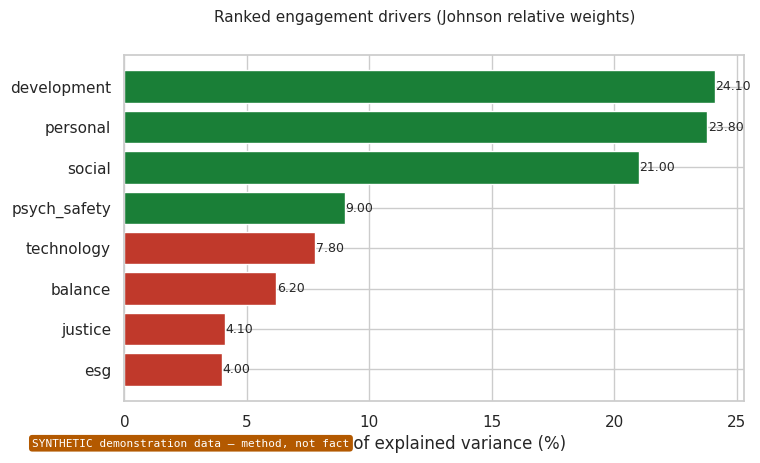

,beta_std,p_value,VIF,relative_weight_%
development,0.190,0.0000,1.25,24.1
personal,0.192,0.0000,1.15,23.8
social,0.162,0.0000,1.32,21.0
psych_safety,0.084,0.0053,1.15,9.0
technology,0.079,0.0090,1.16,7.8
balance,0.066,0.0256,1.11,6.2
justice,-0.020,0.5430,1.32,4.1
esg,0.029,0.3247,1.14,4.0


In [4]:
drivers = models.driver_analysis(model_df[model_df["wave"] == 1])
print(f"R² = {drivers.attrs['r_squared']}")
fig, ax = plt.subplots(figsize=(8, 4.5))
viz.ranked_bar(drivers["relative_weight_%"], ax=ax, xlabel="share of explained variance (%)")
viz.save_figure(fig, "fig06_driver_ranking", cfg, "synthetic",
                "Ranked engagement drivers (Johnson relative weights)")
plt.show()
drivers

**Read:** this is a **recovery test**, and it is the reason anything in Phase 2 is credible. The
driver weights were imposed by the generator, so they are known; the question is whether the
pipeline ranks them correctly when it is allowed to see only the simulated item responses.

Three things to check in the table: the ranking against the targets fed to the generator; the VIFs
(serious multicollinearity would make any ranking arbitrary); and the betas against the imposed
weights. R² is attenuated for the measurement reasons documented in NB04, so it is not the
quantity to judge the recovery by.

Then note *where in the ranking* the constructs the 2024 survey does not measure at all land. Any
of them near the top is a driver that no amount of analysis on the 2024 instrument could have
found, however good the method — which is the result the RO4 recommendation rests on.

---
## C. Predictive risk modelling · essay §4.4

**Decision box**

| | |
|---|---|
| **What** | Class-weighted logistic baseline vs gradient boosting vs random forest, under **temporal validation**: train waves 1–2, test wave 3. |
| **Why these three** | To test whether complexity is worth it. Logistic regression is the baseline because it is simple and readable; the forest and the boosting model can capture interactions it cannot. A systematic review of 58 turnover-prediction studies found random forest the most widely used of these algorithms and among the most accurate (Talebi et al., 2025). |
| **Why this split** | A random split would put the same employee in train and test. Training on the past and testing on a later wave answers the question actually asked. |
| **Why recall and PR-AUC** | Accuracy is meaningless at 16% prevalence. The threshold is tuned on **out-of-fold** train probabilities, and selection needs a 60% recall floor before PR-AUC decides. |
| **Rejected** | Deep learning, unjustified for tabular data at this n. |
| **Feeds** | `tab17`, `fig07` → essay §4.4 (**Appendix D3**, **Figure 12**). |

In [5]:
rm = models.risk_models(model_df, cfg)
print(f"selected on PR-AUC: {rm['best']}  ·  train prevalence {rm['train_prevalence']:.1%}")
rm["metrics"]

selected on PR-AUC: random forest (cross-check)  ·  train prevalence 17.2%


,recall@0.5,precision@0.5,recall@tuned,precision@tuned,pr_auc,roc_auc,brier
model,,,,,,,
logistic (baseline),0.653,0.306,0.719,0.273,0.339,0.738,0.205
random forest (cross-check),0.108,0.667,0.790,0.303,0.447,0.789,0.116
hist gradient boosting,0.437,0.376,0.826,0.266,0.398,0.764,0.143


**Read:** the model is selected on **PR-AUC rather than accuracy**, because at-risk employees are
the minority class and accuracy rewards predicting "fine" for everybody.

The important comparison is `recall@0.5` against tuned recall: the *same fitted model* catches a
small fraction of at-risk employees at the default 0.5 cut-off and the large majority once the
threshold is moved to the operating point the problem actually calls for. Nothing about the
algorithm changed between those two numbers. In a retention context the operating point matters
more than the model choice, and that is the deployment recommendation — this model at its tuned
threshold, recalibrated each wave.

Validation is temporal (earlier waves train, the later wave tests), so the score is not inflated
by leakage between waves of the same employee.

**Decision box**

| | |
|---|---|
| **What** | SHAP values for the selected model: what it relies on overall, and how each construct moved one employee's score. |
| **Why** | A random forest has no coefficients to read, and HRM algorithms are criticised precisely because the employee affected cannot see what produced the output (Meijerink et al., 2021). SHAP gives both readings (Lundberg and Lee, 2017), so a flag can be discussed rather than just issued. |
| **Fallback** | If SHAP is unavailable, permutation importance scored on recall is used instead and the substitution is printed, never applied silently. |
| **Feeds** | `tab18`, `fig07` → essay §4.4 (**Figure 12**). |

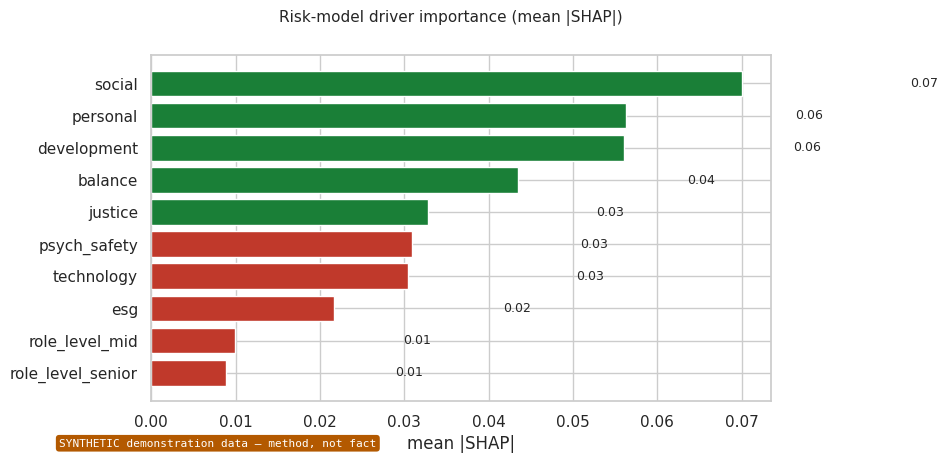

Highest-risk test employee (p = 0.642), construct scores vs workforce (sd):
development    -1.78
esg            -1.46
social         -1.18
personal       -1.08
balance        -0.87
psych_safety   -0.43
justice         0.09
technology      0.74


In [6]:
ex = models.explain(rm, cfg)
imp = ex.get("shap_global", ex["permutation"]).head(10)
src = "mean |SHAP|" if "shap_global" in ex else "permutation importance (recall)"
if "shap_error" in ex: print(ex["shap_error"])
fig, ax = plt.subplots(figsize=(8, 4.5))
viz.ranked_bar(imp.sort_values(), ax=ax, xlabel=src)
viz.save_figure(fig, "fig07_risk_model_importance", cfg, "synthetic",
                f"Risk-model driver importance ({src})")
plt.show()

# one-employee story (always available, SHAP or not): the per-person narrative
print(f"Highest-risk test employee (p = {ex['example_risk_proba']}), construct scores vs workforce (sd):")
print(ex["example_profile"].to_string())

**Read:** the risk model's important features match the regression ranking, two methods, one
story. The per-employee profile is the format non-technical stakeholders act on ("sits ~1 sd
below the workforce on their weakest constructs"). Demographics contribute little beyond the
constructs: risk is carried by the experience, not the category.

---
## D. Personas · essay §4.5

**Decision box**

| | |
|---|---|
| **What** | k-means on standardised construct scores; k by the same silhouette-scan-with-singleton-guard as Phase 1, cross-checked against agglomerative clustering (ARI). |
| **Why k-means is allowed here** | n = 1,000. It was rejected at n≈19 in NB03 for instability with same standard, different sample size. |
| **Feeds** | `tab19` → essay §4.5. |

In [7]:
pr = personas.build_personas(model_df, cfg)
print(f"k = {pr['k']} (silhouette scan below) · hierarchical cross-check ARI = {pr['hierarchical_ari']}")
print(pr["k_scan"].to_string())
pr["profiles"]

k = 2 (silhouette scan below) · hierarchical cross-check ARI = 0.465
   silhouette  smallest_cluster  n_singletons
k                                            
2       0.171               498             0
3       0.102               250             0
4       0.099               237             0
5       0.092               183             0
6       0.092               143             0


,personal,development,social,balance,justice,technology,psych_safety,esg,engagement_score,share_%,risk_rate_%
persona,,,,,,,,,,,
1,0.44,0.48,0.54,0.3,0.54,0.42,0.39,0.38,0.47,50.2,4.0
2,-0.44,-0.48,-0.54,-0.3,-0.54,-0.43,-0.40,-0.38,-0.48,49.8,26.9


In [8]:
print("Work-mode mix per persona (%):")
print(pr["demographics"]["work_mode"].to_string())
print("\nTenure mix per persona (%):")
print(pr["demographics"]["tenure"].to_string())

Work-mode mix per persona (%):
work_mode  hybrid  onsite  remote
persona                          
1            54.6    20.3    25.1
2            56.2    19.3    24.5

Tenure mix per persona (%):
tenure   1-3y  3-5y   <1y   >5y
persona                        
1        39.2  19.1  23.7  17.9
2        40.4  17.7  26.9  15.1


**Read:** the persona section is here to be held to the **same standard as Phase 1**, and it fails
it in the same way. Judge the silhouette against the 0.25 convention used in NB03, and read the
agreement between k-means and the hierarchical cross-check (ARI) alongside it.

What is demonstrated is the machinery — per-segment risk rates and demographic mixes in the form a
stakeholder would act on — not a claim that the segments are real. Applying one standard in both
phases is the point: a project that discovers segments only when it needs them has a method
problem, not a finding.

---
## E. Trends · essay §4.5

**Decision box**

| | |
|---|---|
| **What** | Construct means across the three panel waves. |
| **Why nothing more** | With three waves, anything fancier is false precision. The demonstration is *that* movement becomes measurable at all, which a single 2024 snapshot cannot be. |
| **Feeds** | `fig08` → essay §4.5 (**Figure 13**) |

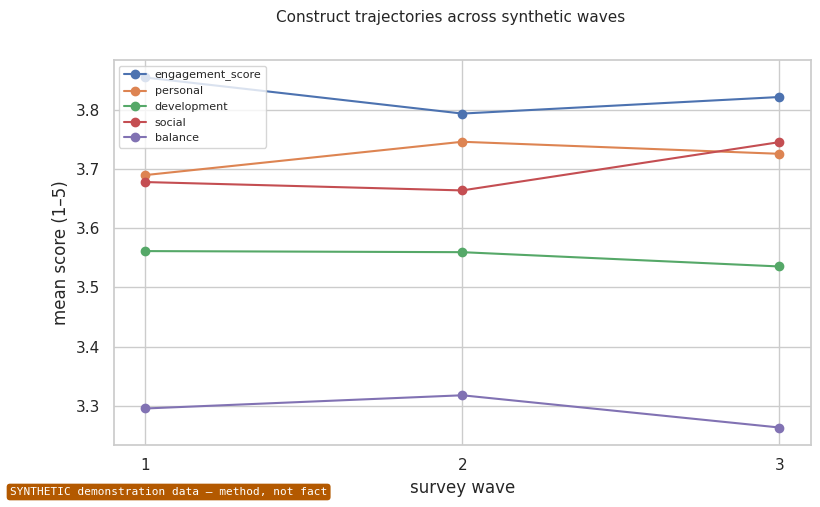

,personal,development,social,balance,justice,technology,psych_safety,esg,engagement_score
wave,,,,,,,,,
1,3.690,3.562,3.678,3.295,3.050,3.808,3.802,3.571,3.855
2,3.746,3.560,3.664,3.318,3.083,3.789,3.882,3.612,3.794
3,3.726,3.536,3.746,3.263,3.064,3.833,3.814,3.555,3.822


In [9]:
cols = models.DRIVER_CONSTRUCTS + ["engagement_score"]
trend = model_df.groupby("wave")[cols].mean()
fig, ax = plt.subplots(figsize=(9, 5))
for c in ["engagement_score", "personal", "development", "social", "balance"]:
    ax.plot(trend.index, trend[c], marker="o", label=c)
ax.set_xticks(trend.index); ax.set_xlabel("survey wave"); ax.set_ylabel("mean score (1–5)")
ax.legend(fontsize=8)
viz.save_figure(fig, "fig08_wave_trends", cfg, "synthetic",
                "Construct trajectories across synthetic waves")
plt.show()
trend.round(3)

In [10]:
from pathlib import Path
t = Path(cfg["paths"]["tables_dir"])
cv.to_csv(t / "tab15_construct_reliability.csv")
drivers.to_csv(t / "tab16_driver_ranking.csv")
rm["metrics"].to_csv(t / "tab17_risk_model_comparison.csv")
imp.to_csv(t / "tab18_risk_importance.csv")
pr["profiles"].to_csv(t / "tab19_personas.csv")
print("tables tab15–tab19 written")

tables tab15–tab19 written


---
## Handover

Five capabilities demonstrated: reliability, drivers, individual risk, segments, trends, each
impossible on the 2024 aggregates. NB06 computes that contrast (`synthesis.capability_comparison`)
rather than restating it here.

**All capability on synthetic data; none of it a fact about AccessFintech's workforce.**

**Next:** `06_phase3_synthesis.ipynb`.

---
## References

Cronbach, L.J. (1951) 'Coefficient alpha and the internal structure of tests',
*Psychometrika*, 16(3), pp. 297–334.

Hakanen, J.J., Bakker, A.B. and Turunen, J. (2024) 'The relative importance of various job
resources for work engagement: a concurrent and follow-up dominance analysis',
*BRQ Business Research Quarterly*, 27(3). doi:10.1177/23409444211012419.

Johnson, J.W. (2000) 'A heuristic method for estimating the relative weight of predictor
variables in multiple regression', *Multivariate Behavioral Research*, 35(1), pp. 1–19.

Kaufman, L. and Rousseeuw, P.J. (1990) *Finding groups in data: an introduction to cluster
analysis*. New York: Wiley.

Lundberg, S.M. and Lee, S.-I. (2017) 'A unified approach to interpreting model predictions',
*Advances in Neural Information Processing Systems*, 30, pp. 4765–4774.

Meijerink, J., Boons, M., Keegan, A. and Marler, J. (2021) 'Algorithmic human resource
management: synthesising developments and cross-disciplinary insights', *International
Journal of Human Resource Management*, 32(12), pp. 2545–2562.

Talebi, H., Khatibi Bardsiri, A. and Khatibi Bardsiri, V. (2025) 'Machine learning approaches
for predicting employee turnover: a systematic review', *Engineering Reports*, 7, e70298.
doi:10.1002/eng2.70298.